In [45]:
# [1] ==============================
# ✅ 실험 상수

SYMBOL = 'AAPL'
START_DATE = '2017-01-01'
END_DATE = '2024-01-01'
SPLIT_DATE = '2022-01-01'

WINDOW_SIZE = 60
SCALER_TYPE = 'minmax'
BATCH_SIZE = 64
EPOCHS = 100
LSTM_UNITS = 64
DROPOUT_RATE = 0.2
LEARNING_RATE = 0.001
EARLYSTOPPING_PATIENCE = 40

TOP_N_FEATURES = 8
ROLLING_ALLOWANCE = 40

print("✅ 실험 상수 설정 완료")


✅ 실험 상수 설정 완료


In [3]:
# [2] ==============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas_ta as ta
import yfinance as yf
from ta import add_all_ta_features

from sklearn.preprocessing import MinMaxScaler, RobustScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dropout, Dense
from tensorflow.keras.callbacks import EarlyStopping

from xgboost import XGBRegressor

print("✅ 라이브러리 임포트 완료")


/home/nshawny/anaconda3/envs/dl-gpu/lib/python3.10/site-packages/pandas_ta/__init__.py:7: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound
2025-07-02 15:58:08.402215: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-07-02 15:58:08.814319: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate co

✅ 라이브러리 임포트 완료


In [4]:
# [3] ==============================
ticker=yf.Ticker(SYMBOL)
df_raw = ticker.history(start=START_DATE, end=END_DATE, interval='1d').reset_index()
print(df_raw.head())
print(f"✅ 다운로드 완료: {SYMBOL} {START_DATE} ~ {END_DATE}")


                       Date       Open       High        Low      Close  \
0 2017-01-03 00:00:00-05:00  26.746408  26.868822  26.506198  26.827248   
1 2017-01-04 00:00:00-05:00  26.757958  26.910399  26.734861  26.797222   
2 2017-01-05 00:00:00-05:00  26.774122  26.991235  26.748715  26.933493   
3 2017-01-06 00:00:00-05:00  26.972759  27.291500  26.901159  27.233757   
4 2017-01-09 00:00:00-05:00  27.242990  27.584828  27.240682  27.483200   

      Volume  Dividends  Stock Splits  
0  115127600        0.0           0.0  
1   84472400        0.0           0.0  
2   88774400        0.0           0.0  
3  127007600        0.0           0.0  
4  134247600        0.0           0.0  
✅ 다운로드 완료: AAPL 2017-01-01 ~ 2024-01-01


In [26]:
# [4] ==============================
# ✅ add_all_ta_features로 한 번에
df = df_raw.copy()
df = add_all_ta_features(
    df, open="Open", high="High", low="Low", close="Close", volume="Volume", fillna=False
)

# ✅ 타겟 컬럼
df['Target_Close'] = df['Close'].shift(-1)



# ✅ 원본 백업
df_temp = df.copy()

print(f"✅ 기술지표 추가 완료 / 최종 컬럼수: {df.shape[1]}")


✅ 기술지표 추가 완료 / 최종 컬럼수: 95


In [27]:
cols_to_drop = [
    'trend_trix',
    'trend_stc',
    'trend_visual_ichimoku_a',
    'trend_psar_up',
    'trend_psar_down'
]

df = df.drop(columns=cols_to_drop, errors='ignore')
print(f"✅ 문제 컬럼 제거 완료. 현재 컬럼수: {df.shape[1]}")

✅ 문제 컬럼 제거 완료. 현재 컬럼수: 90


In [53]:
# ✅ NaN 제거
df = df.dropna().reset_index(drop=True)

In [54]:
# ✅ 원본 백업
df_temp2 = df.copy()

In [55]:
# [6] ==============================
df["Date"] = pd.to_datetime(df["Date"])

train_df = df[df["Date"] < SPLIT_DATE].copy()
test_df = df[df["Date"] >= SPLIT_DATE].copy()

print(f"✅ Train 기간: {train_df['Date'].min()} ~ {train_df['Date'].max()}")
print(f"✅ Test 기간: {test_df['Date'].min()} ~ {test_df['Date'].max()}")


✅ Train 기간: 2017-03-02 00:00:00-05:00 ~ 2021-12-31 00:00:00-05:00
✅ Test 기간: 2022-01-03 00:00:00-05:00 ~ 2023-12-28 00:00:00-05:00


In [56]:
# [7] ==============================
feature_cols_all = df.columns.drop(['Date', 'Target_Close'])

X_train_all = train_df[feature_cols_all]
y_train_all = train_df['Target_Close']

xgb = XGBRegressor(n_estimators=100, max_depth=6)
xgb.fit(X_train_all, y_train_all)

importances = pd.Series(xgb.feature_importances_, index=feature_cols_all)
top_features = importances.sort_values(ascending=False).head(TOP_N_FEATURES).index.tolist()

print("✅ 상위 Feature:")
print(top_features)


✅ 상위 Feature:
['trend_ichimoku_base', 'volatility_dch', 'High', 'volume_vwap', 'Low', 'Close', 'volatility_bbl', 'Open']


In [57]:
top_features

['trend_ichimoku_base',
 'volatility_dch',
 'High',
 'volume_vwap',
 'Low',
 'Close',
 'volatility_bbl',
 'Open']

In [58]:
df[top_features].corr(method='spearman')

,trend_ichimoku_base,volatility_dch,High,volume_vwap,Low,Close,volatility_bbl,Open
trend_ichimoku_base,1.000000,0.997362,0.991115,0.996517,0.990047,0.990286,0.995340,0.990795
volatility_dch,0.997362,1.000000,0.991167,0.996029,0.989532,0.990073,0.991348,0.990628
High,0.991115,0.991167,1.000000,0.995454,0.999520,0.999566,0.991726,0.999632
volume_vwap,0.996517,0.996029,0.995454,1.000000,0.994909,0.994792,0.997083,0.995486
Low,0.990047,0.989532,0.999520,0.994909,1.000000,0.999584,0.991572,0.999571
Close,0.990286,0.990073,0.999566,0.994792,0.999584,1.000000,0.991258,0.999066
volatility_bbl,0.995340,0.991348,0.991726,0.997083,0.991572,0.991258,1.000000,0.991872
Open,0.990795,0.990628,0.999632,0.995486,0.999571,0.999066,0.991872,1.000000


In [59]:
SELECTED_FEATURES = [
    'Close',
    'trend_ema_fast',
    'volatility_bbm',
    'trend_ichimoku_conv',
    'volume_obv',
    'trend_macd'
]

In [60]:
df[SELECTED_FEATURES].corr()

,Close,trend_ema_fast,volatility_bbm,trend_ichimoku_conv,volume_obv,trend_macd
Close,1.000000,0.998350,0.995992,0.998243,0.937137,0.178110
trend_ema_fast,0.998350,1.000000,0.999257,0.999766,0.933506,0.144731
volatility_bbm,0.995992,0.999257,1.000000,0.998716,0.929672,0.113410
trend_ichimoku_conv,0.998243,0.999766,0.998716,1.000000,0.934338,0.155708
volume_obv,0.937137,0.933506,0.929672,0.934338,1.000000,0.245914
trend_macd,0.178110,0.144731,0.113410,0.155708,0.245914,1.000000


In [61]:
# [8] ==============================
if SCALER_TYPE == 'minmax':
    feature_scaler = MinMaxScaler()
else:
    feature_scaler = RobustScaler()

feature_scaler.fit(train_df[top_features])

train_scaled = feature_scaler.transform(train_df[top_features])
test_scaled = feature_scaler.transform(test_df[top_features])

target_scaler = MinMaxScaler()
target_scaler.fit(train_df[['Target_Close']])

train_target_scaled = target_scaler.transform(train_df[['Target_Close']]).flatten()
test_target_scaled = target_scaler.transform(test_df[['Target_Close']]).flatten()

print("✅ 스케일링 완료")

✅ 스케일링 완료


In [62]:
# [9] ==============================
def create_window_data(X, y, window_size):
    Xs, ys = [], []
    for i in range(window_size, len(X)):
        Xs.append(X[i - window_size:i])
        ys.append(y[i])
    return np.array(Xs), np.array(ys)

X_train, y_train = create_window_data(train_scaled, train_target_scaled, WINDOW_SIZE)
X_test, y_test = create_window_data(test_scaled, test_target_scaled, WINDOW_SIZE)

print(f"✅ 윈도우 데이터 생성 완료: X_train {X_train.shape}, X_test {X_test.shape}")


✅ 윈도우 데이터 생성 완료: X_train (1159, 60, 8), X_test (440, 60, 8)


In [63]:
# [10] ==============================
model = Sequential([
    LSTM(LSTM_UNITS, input_shape=(WINDOW_SIZE, X_train.shape[2])),
    Dropout(DROPOUT_RATE),
    Dense(1)
])
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE), loss='mse')

earlystop = EarlyStopping(patience=EARLYSTOPPING_PATIENCE, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[earlystop],
    verbose=2
)

print("✅ 모델 학습 완료")


Epoch 1/100


2025-07-02 16:25:12.396207: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2025-07-02 16:25:12.398916: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2025-07-02 16:25:12.400550: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus

17/17 - 2s - loss: 0.0107 - val_loss: 0.0386 - 2s/epoch - 108ms/step
Epoch 2/100


2025-07-02 16:25:14.208317: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2025-07-02 16:25:14.210691: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2025-07-02 16:25:14.213076: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus

17/17 - 0s - loss: 0.0035 - val_loss: 0.0049 - 195ms/epoch - 11ms/step
Epoch 3/100
17/17 - 0s - loss: 0.0021 - val_loss: 0.0017 - 192ms/epoch - 11ms/step
Epoch 4/100
17/17 - 0s - loss: 0.0019 - val_loss: 0.0020 - 193ms/epoch - 11ms/step
Epoch 5/100
17/17 - 0s - loss: 0.0017 - val_loss: 0.0033 - 201ms/epoch - 12ms/step
Epoch 6/100
17/17 - 0s - loss: 0.0017 - val_loss: 0.0037 - 185ms/epoch - 11ms/step
Epoch 7/100
17/17 - 0s - loss: 0.0016 - val_loss: 0.0018 - 189ms/epoch - 11ms/step
Epoch 8/100
17/17 - 0s - loss: 0.0015 - val_loss: 0.0012 - 184ms/epoch - 11ms/step
Epoch 9/100
17/17 - 0s - loss: 0.0011 - val_loss: 0.0018 - 178ms/epoch - 10ms/step
Epoch 10/100
17/17 - 0s - loss: 0.0013 - val_loss: 0.0014 - 198ms/epoch - 12ms/step
Epoch 11/100
17/17 - 0s - loss: 0.0012 - val_loss: 0.0013 - 180ms/epoch - 11ms/step
Epoch 12/100
17/17 - 0s - loss: 0.0011 - val_loss: 0.0011 - 176ms/epoch - 10ms/step
Epoch 13/100
17/17 - 0s - loss: 0.0011 - val_loss: 0.0017 - 177ms/epoch - 10ms/step
Epoch 14/100

11/37 [=======>......................] - ETA: 0s

2025-07-02 16:25:33.936058: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2025-07-02 16:25:33.938096: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2025-07-02 16:25:33.939022: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus

14/14 [==============================] - 0s 5ms/step
✅ 예측 및 역변환 완료
✅ RMSE: 4.58
✅ MAE: 3.70
✅ R²: 0.9402


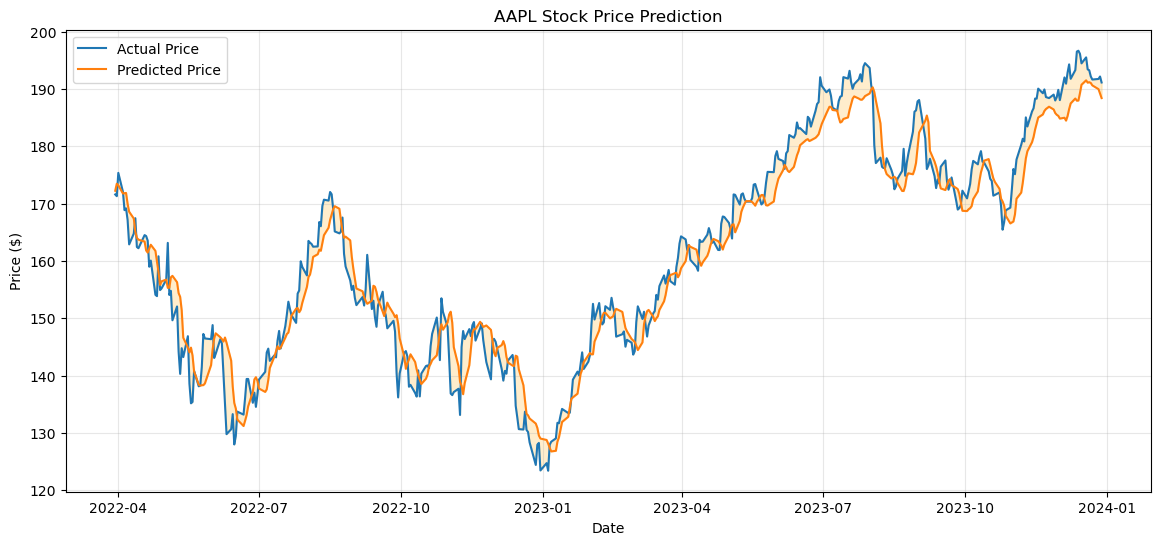

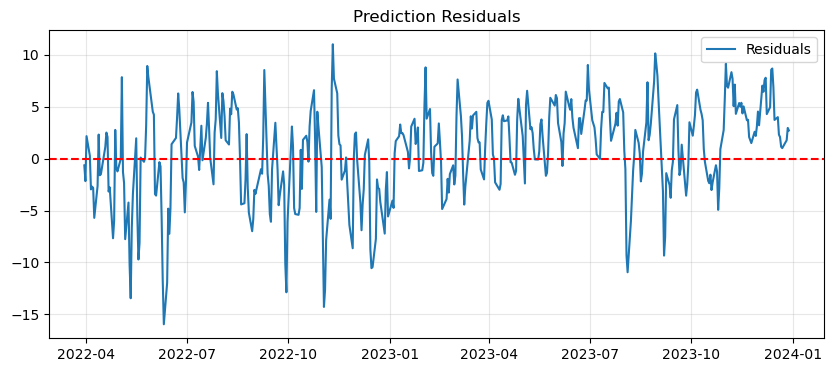

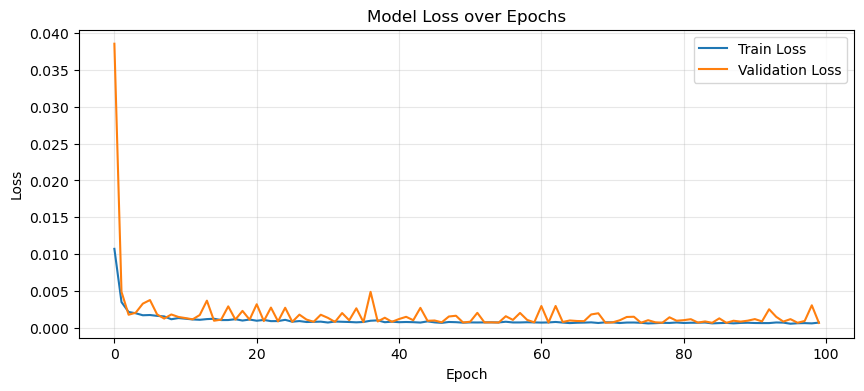

In [64]:
# [11] ==============================
pred_train_scaled = model.predict(X_train).flatten()
pred_test_scaled = model.predict(X_test).flatten()

train_predicted = target_scaler.inverse_transform(pred_train_scaled.reshape(-1,1)).flatten()
test_predicted = target_scaler.inverse_transform(pred_test_scaled.reshape(-1,1)).flatten()

train_actual = target_scaler.inverse_transform(y_train.reshape(-1,1)).flatten()
test_actual = target_scaler.inverse_transform(y_test.reshape(-1,1)).flatten()

print("✅ 예측 및 역변환 완료")

rmse = np.sqrt(mean_squared_error(test_actual, test_predicted))
mae = mean_absolute_error(test_actual, test_predicted)
r2 = r2_score(test_actual, test_predicted)

print(f"✅ RMSE: {rmse:.2f}")
print(f"✅ MAE: {mae:.2f}")
print(f"✅ R²: {r2:.4f}")

test_dates = test_df["Date"].values[WINDOW_SIZE:]

plt.figure(figsize=(14,6))
plt.plot(test_dates, test_actual, label='Actual Price')
plt.plot(test_dates, test_predicted, label='Predicted Price')
plt.fill_between(test_dates, test_actual, test_predicted, color='orange', alpha=0.2)
plt.title(f'{SYMBOL} Stock Price Prediction')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(10,4))
plt.plot(test_dates, test_actual - test_predicted, label='Residuals')
plt.axhline(0, color='red', linestyle='--')
plt.title('Prediction Residuals')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(10,4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(alpha=0.3)
plt.show()
